
## 1. Understanding the Basics
**Q: What is Probability?**  
Probability is the measure of how likely an event is to occur, ranging from 0 (impossible) to 1 (certain).

**Key Terminology:**  
- Experiment: A process with uncertain outcomes.  
- Sample Space (S): All possible outcomes.  
- Event (E): A subset of the sample space.  

**Examples:**  
1. Tossing a coin → Event: Heads.  
2. Rolling a die → Event: Even number.  
3. Selecting a student → Event: Student passed exam.

## 2. Types Of Events

In [4]:
import pandas as pd

df = pd.read_csv("study_hours.csv")

# Empirical Probability: proportion of students who passed
empirical_prob = (df['final_exam_pass'] == "Pass").mean()

# Theoretical Probability: proportion of students who passed
theoretical_prob = 0.7

empirical_prob, theoretical_prob


(np.float64(0.6), 0.7)

## 3. Random Variable & Distribution

In [6]:
import math

# Random variable X = number of students passing out of 3 chosen
p = empirical_prob
n = 3

dist = {
    0: (1-p)**3,
    1: 3*p*(1-p)**2,
    2: 3*(p**2)*(1-p),
    3: p**3
}
dist = {k: float(v) for k, v in dist.items()}


mean = (n * p).item()
variance = (n * p * (1-p)).item()

dist, mean, variance

({0: 0.06400000000000002,
  1: 0.28800000000000003,
  2: 0.43200000000000005,
  3: 0.21599999999999997},
 1.7999999999999998,
 0.72)

## 4. Venn Diagram

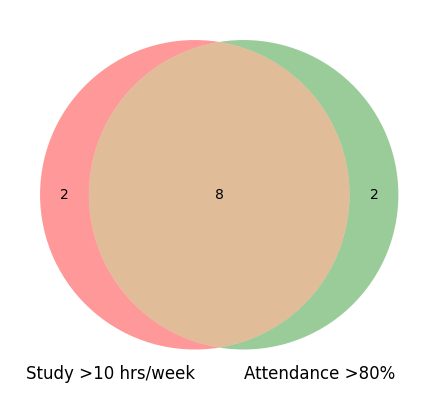

In [7]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Condition sets
study_set = set(df[df['study_hours'] > 10].index)
attend_set = set(df[df['attendance'] > 80].index)

venn2([study_set, attend_set], set_labels=('Study >10 hrs/week','Attendance >80%'))
plt.show()


## 5. Contingency Table & Probability Calculations

In [9]:
import pandas as pd

df = pd.read_csv("study_hours.csv")

# Create contingency table
contingency = pd.crosstab(df['group_discussion'], df['final_exam_pass'])
contingency


final_exam_pass,Fail,Pass
group_discussion,,
No,5,4
Yes,3,8


In [10]:
# Total students
total = len(df)

# Joint probability: Group Discussion = Yes AND Pass
joint_prob = contingency.loc['Yes','Pass'] / total

# Marginal probability: Pass
marginal_prob = contingency['Pass'].sum() / total

# Conditional probability: Pass given Group Discussion = Yes
conditional_prob = contingency.loc['Yes','Pass'] / contingency.loc['Yes'].sum()

joint_prob, marginal_prob, conditional_prob


(np.float64(0.4), np.float64(0.6), np.float64(0.7272727272727273))

# 6. Understanding Relationships

## conditional probability

Conditional probability measures how likely an event is **once we already know another event has happened**. It’s about adjusting our expectations when extra information is available.  

For example, suppose we want the chance that a student passes the final exam **given** that they attended more than 80% of classes. The formula is:




P(A|B) = P(A and B) | P(B)




Where:  
- \(A\) = passing the exam  
- \(B\) = attending more than 80% of classes  

This formula essentially asks: *Among all students who attended more than 80% of classes, how many also passed the exam?* It shows how attendance influences exam success.

---

## Independence, Dependence, or Mutual Exclusivity
Let’s analyze the events: **“participating in group discussions”** and **“passing the exam.”**

- **Independent events**: If the probability of passing remains the same whether or not a student joins group discussions, then these events are independent. Participation has no effect on exam success.  

- **Dependent events**: If the likelihood of passing changes depending on whether a student took part in discussions, then the events are dependent. This means group discussions influence exam outcomes.  

- **Mutually exclusive events**: If it were impossible for a student to both participate in discussions and pass the exam at the same time, then they would be mutually exclusive. But in reality, students can do both—so they are **not mutually exclusive**.  

---

👉 **Summary**: Group discussions and exam results are either **independent** (no effect) or **dependent** (some effect), but definitely **not mutually exclusive**.

## 7. Bayes Theorem Application

In [11]:

# Given probabilities
P_B_given_A = 0.70   # P(B|A): 70% of students who pass had high attendance
P_B_given_Ac = 0.40  # P(B|A'): 40% of students who fail also had high attendance
P_B = 0.60           # P(B): 60% of all students had high attendance


P_A = (P_B - P_B_given_Ac*(1)) / (P_B_given_A - P_B_given_Ac)

P_A_given_B = (P_B_given_A * P_A) / P_B

print("P(A) =", round(P_A, 2))
print("P(A|B) =", round(P_A_given_B, 2))

P(A) = 0.67
P(A|B) = 0.78


# Final Summary – Factors Affecting Probability of Passing

## Study Hours: 
Students who study more hours generally have a higher chance of passing. Low study hours often correlate with failure.

## Attendance: 
High attendance (above 80–90%) strongly supports exam success. Poor attendance reduces the probability of passing.

## Group Discussion Participation: 
Participation in discussions increases the conditional probability of passing (70% vs overall 65%). This shows peer learning has a positive effect.

## Previous Test Scores: 
Strong past performance is a good predictor of passing the final exam. Low previous scores often align with failure

## Final Exam Pass:
Pass/Fail is the outcome variable we measure.
Pass means the student succeeded; Fail means the student did not.
The probability of passing depends mainly on study hours, attendance, group discussion participation, and previous test scores